# Fashion-MNIST — clustering results report

Interactive view of `results.csv` and figures under `figures/`.

**Run Jupyter from the project root** (same folder as `main.py`).

```bash
pip install jupyter ipywidgets
jupyter notebook results_report.ipynb
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd()
if not (ROOT / "results.csv").exists():
    raise FileNotFoundError(
        "results.csv not found. cd to the project directory or set ROOT to the repo path."
    )

CSV_PATH = ROOT / "results.csv"
FIG_DIR = ROOT / "figures"

df = pd.read_csv(CSV_PATH)
df.head()

,DimReduction,Clustering,DR_TrainTime_s,Clust_Time_s,N_Clusters_found,CalinskiHarabasz,DaviesBouldin,Silhouette,AdjRandIndex
0,Raw,MiniBatchKMeans,0.0,0.411,10,1208.817505,2.110671,0.143972,0.338525
1,Raw,DBSCAN,0.0,0.078,2,5.985200,1.192719,0.064567,-0.000004
2,Raw,AgglomerativeClustering,0.0,2.909,10,1525.146606,1.665886,0.165148,0.369263
3,Raw,GaussianMixture,0.0,5.081,10,1070.161743,2.525685,0.128994,0.395646
4,Raw,Birch,0.0,2.730,10,1580.538208,1.562193,0.189793,0.371293


## Full results table

Higher is better: **Calinski–Harabasz**, **Silhouette**, **Adjusted Rand**.  
Lower is better: **Davies–Bouldin**.

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}" if pd.notna(x) else "")
display(df)

,DimReduction,Clustering,DR_TrainTime_s,Clust_Time_s,N_Clusters_found,CalinskiHarabasz,DaviesBouldin,Silhouette,AdjRandIndex
0,Raw,MiniBatchKMeans,0.0000,0.4110,10,1208.8175,2.1107,0.1440,0.3385
1,Raw,DBSCAN,0.0000,0.0780,2,5.9852,1.1927,0.0646,-0.0000
2,Raw,AgglomerativeClustering,0.0000,2.9090,10,1525.1466,1.6659,0.1651,0.3693
3,Raw,GaussianMixture,0.0000,5.0810,10,1070.1617,2.5257,0.1290,0.3956
4,Raw,Birch,0.0000,2.7300,10,1580.5382,1.5622,0.1898,0.3713
5,PCA,MiniBatchKMeans,0.1110,0.0370,10,1609.5312,1.7639,0.1754,0.3562
6,PCA,DBSCAN,0.1110,0.0860,3,4.9212,1.0608,0.0631,0.0000
7,PCA,AgglomerativeClustering,0.1110,2.9280,10,1574.6073,1.5511,0.1848,0.3931
8,PCA,GaussianMixture,0.1110,4.5410,10,1094.0779,2.6619,0.1276,0.4174
9,PCA,Birch,0.1110,2.8060,10,1592.5935,1.5763,0.1885,0.3647


## Best runs (by metric)

Rows with missing metrics (e.g. single-cluster DBSCAN) are skipped where needed.

In [3]:
def best_row(series_col, higher=True):
    s = df[series_col].dropna()
    if s.empty:
        return None
    idx = s.idxmax() if higher else s.idxmin()
    return df.loc[idx]

summary = pd.DataFrame(
    {
        "metric": [
            "Silhouette (↑)",
            "Calinski–Harabasz (↑)",
            "Davies–Bouldin (↓)",
            "Adjusted Rand (↑)",
        ],
        "DimReduction": [
            best_row("Silhouette")["DimReduction"],
            best_row("CalinskiHarabasz")["DimReduction"],
            best_row("DaviesBouldin", higher=False)["DimReduction"],
            best_row("AdjRandIndex")["DimReduction"],
        ],
        "Clustering": [
            best_row("Silhouette")["Clustering"],
            best_row("CalinskiHarabasz")["Clustering"],
            best_row("DaviesBouldin", higher=False)["Clustering"],
            best_row("AdjRandIndex")["Clustering"],
        ],
        "value": [
            best_row("Silhouette")["Silhouette"],
            best_row("CalinskiHarabasz")["CalinskiHarabasz"],
            best_row("DaviesBouldin", higher=False)["DaviesBouldin"],
            best_row("AdjRandIndex")["AdjRandIndex"],
        ],
    }
)
display(summary)

,metric,DimReduction,Clustering,value
0,Silhouette (↑),UMAP,AgglomerativeClustering,0.4893
1,Calinski–Harabasz (↑),UMAP,AgglomerativeClustering,20009.5703
2,Davies–Bouldin (↓),UMAP,AgglomerativeClustering,0.7147
3,Adjusted Rand (↑),UMAP,Birch,0.4704


## Heatmaps (DR × clustering algorithm)

**Davies–Bouldin:** colour uses **negative** values so that **darker = better** (same intuition as other panels).

/Users/stanimeros/Documents/csc/fashion-mnist-clustering-and-visualization/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/stanimeros/Documents/csc/fashion-mnist-clustering-and-visualization/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/stanimeros/Documents/csc/fashion-mnist-clustering-and-visualization/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/stanimeros/Documents/csc/fashion-mnist-clustering-and-visualization/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


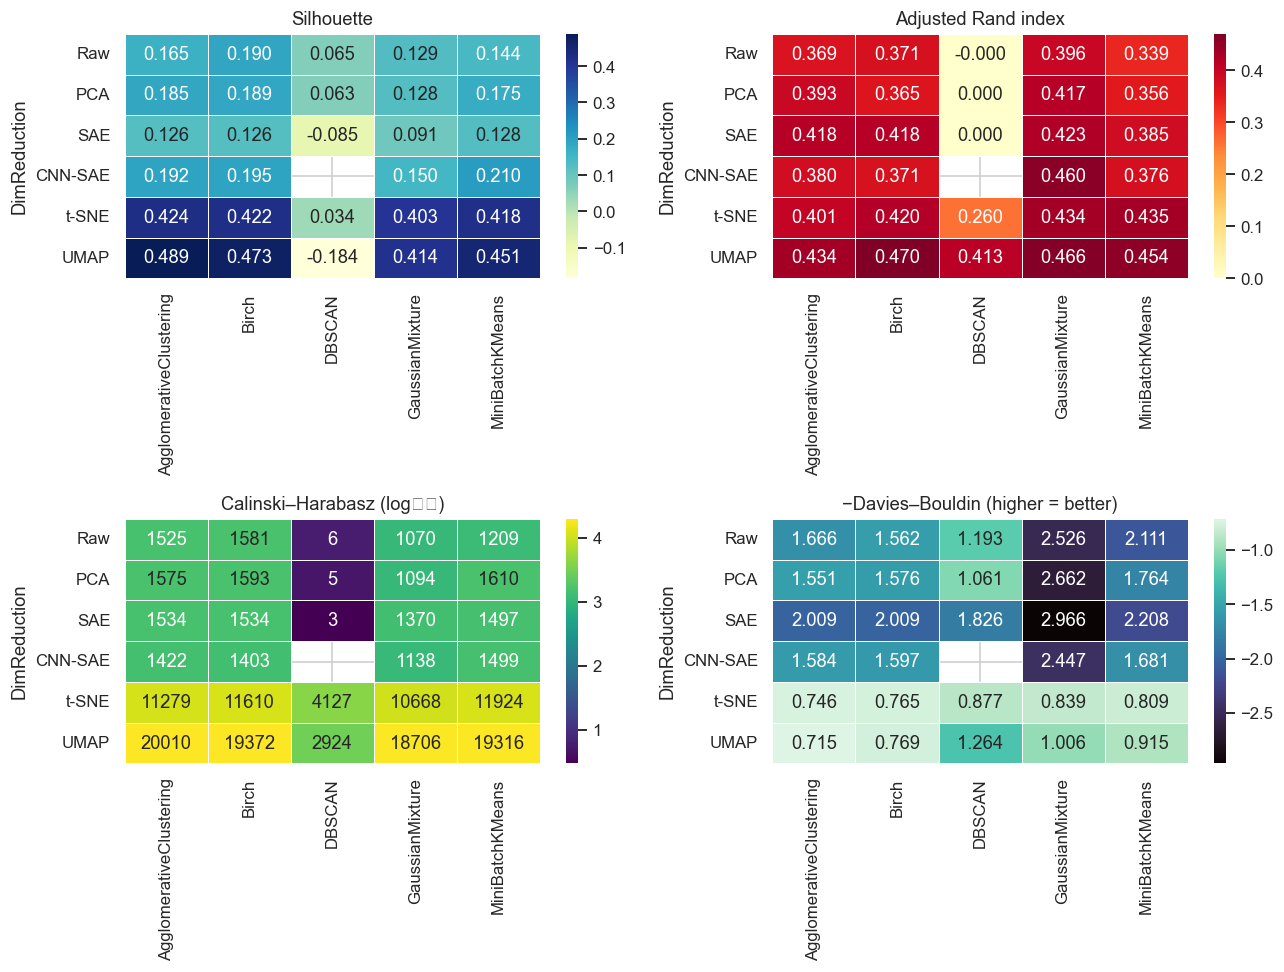

In [4]:
def pivot(metric):
    p = df.pivot(index="DimReduction", columns="Clustering", values=metric)
    order_dr = [x for x in ["Raw", "PCA", "SAE", "CNN-SAE", "t-SNE", "UMAP"] if x in p.index]
    p = p.reindex(order_dr)
    return p

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
metrics = [
    ("Silhouette", "Silhouette", "YlGnBu"),
    ("AdjRandIndex", "Adjusted Rand index", "YlOrRd"),
    ("CalinskiHarabasz", "Calinski–Harabasz (log₁₀)", "viridis"),
    ("DaviesBouldin", "−Davies–Bouldin (higher = better)", "mako"),
]

for ax, (col, title, cmap) in zip(axes.ravel(), metrics):
    p = pivot(col)
    if col == "CalinskiHarabasz":
        plot_p = np.log10(p.clip(lower=1e-12))
        annot = p.map(lambda v: f"{v:.0f}" if pd.notna(v) else "")
    elif col == "DaviesBouldin":
        plot_p = -p
        annot = p.map(lambda v: f"{v:.3f}" if pd.notna(v) else "")
    else:
        plot_p = p
        annot = p.map(lambda v: f"{v:.3f}" if pd.notna(v) else "")
    sns.heatmap(
        plot_p,
        ax=ax,
        cmap=cmap,
        annot=annot,
        fmt="",
        linewidths=0.5,
    )
    ax.set_title(title)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Training / clustering time

Per **dimensionality reduction** block: DR training time is shared across all clustering rows for that DR.

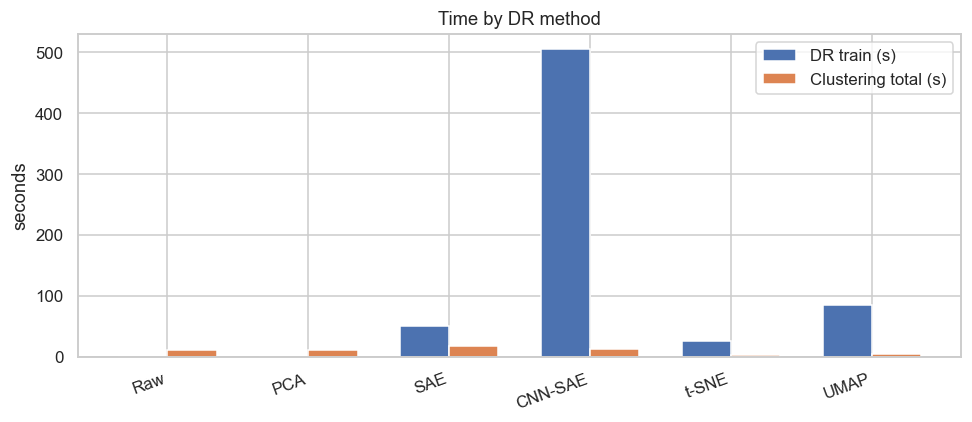

,DR_train_s,clustering_sum_s
DimReduction,,
Raw,0.0000,11.2090
PCA,0.1110,10.3980
SAE,50.5300,16.9600
CNN-SAE,505.4070,12.1600
t-SNE,26.3710,2.4880
UMAP,85.2920,4.7870


In [5]:
dr_order = [x for x in ["Raw", "PCA", "SAE", "CNN-SAE", "t-SNE", "UMAP"] if x in set(df["DimReduction"])]
t_dr = df.groupby("DimReduction", sort=False)["DR_TrainTime_s"].first().reindex(dr_order)
t_clust = df.groupby("DimReduction", sort=False)["Clust_Time_s"].sum().reindex(dr_order)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(dr_order))
w = 0.35
ax.bar(x - w / 2, t_dr, w, label="DR train (s)")
ax.bar(x + w / 2, t_clust, w, label="Clustering total (s)")
ax.set_xticks(x)
ax.set_xticklabels(dr_order, rotation=20, ha="right")
ax.set_ylabel("seconds")
ax.legend()
ax.set_title("Time by DR method")
plt.tight_layout()
plt.show()

pd.DataFrame({"DR_train_s": t_dr, "clustering_sum_s": t_clust})

## Figures

PNG files generated by `main.py` (paths relative to project root).

### `00_sample_images.png`

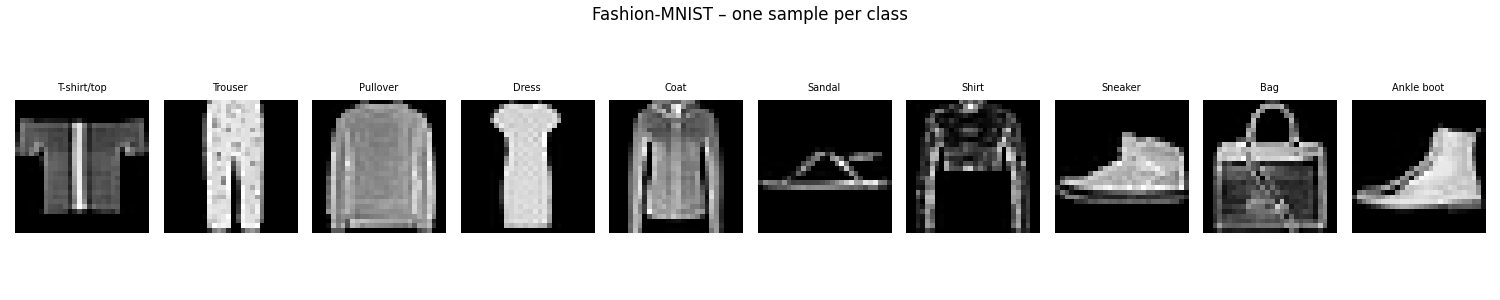

### `pca_explained_variance.png`

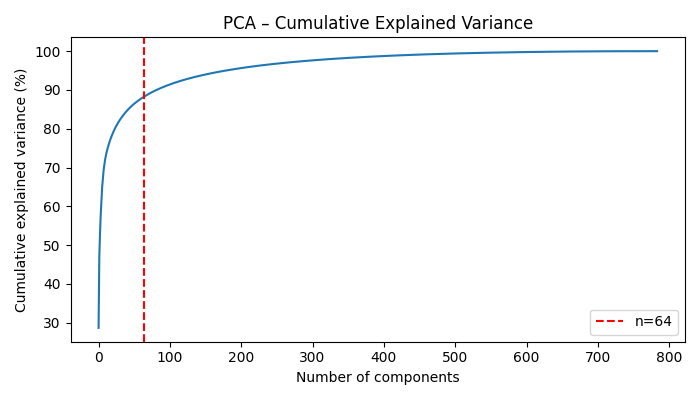

### `sae_reconstructions.png`

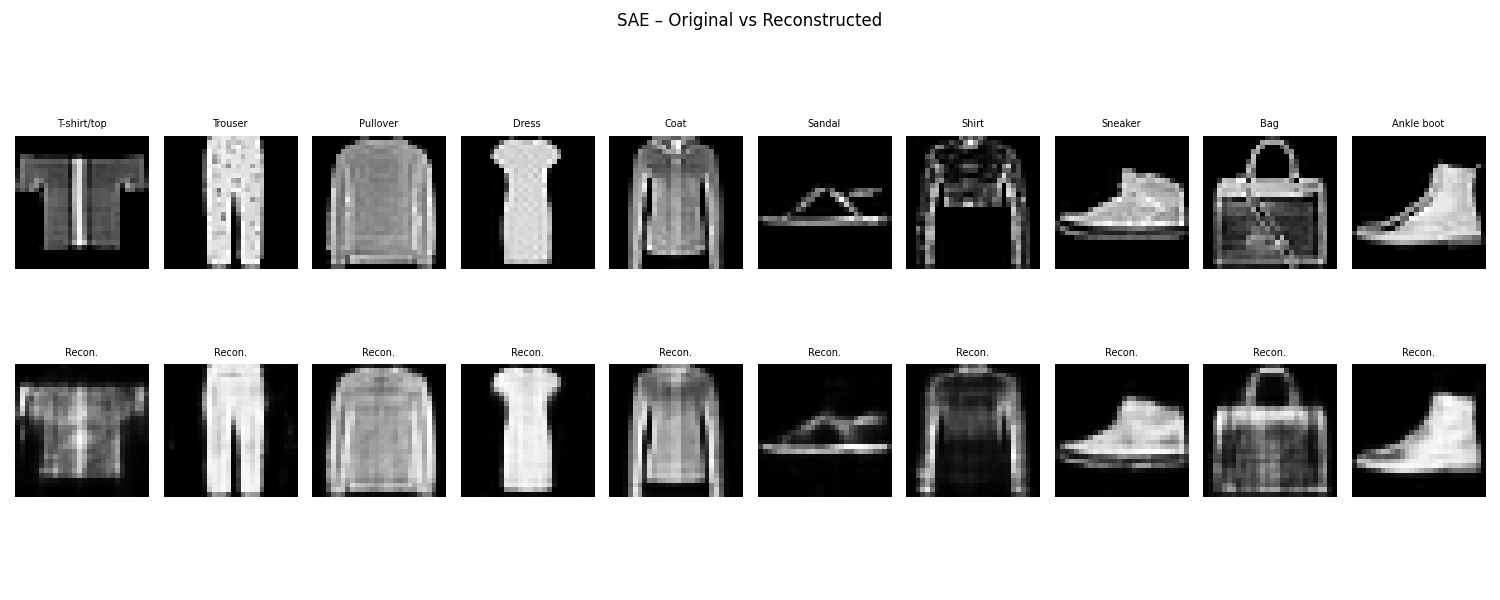

### `cnnsae_reconstructions.png`

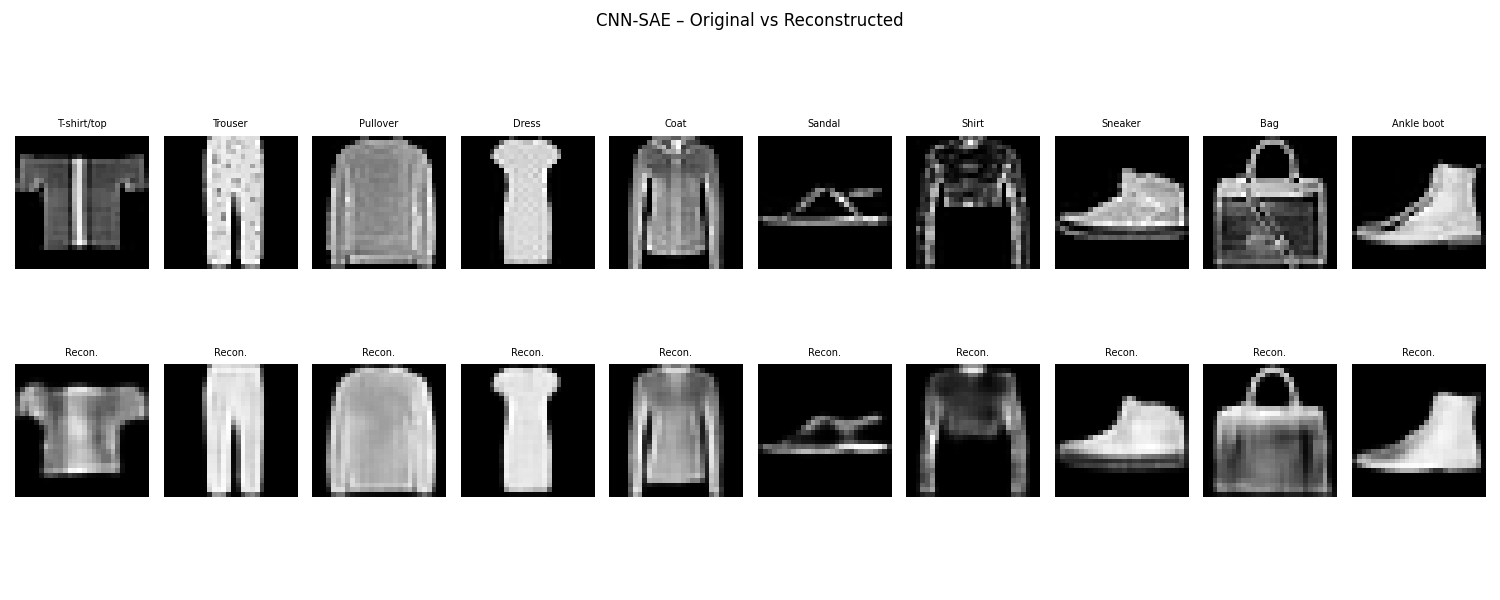

### `umap_2d.png`

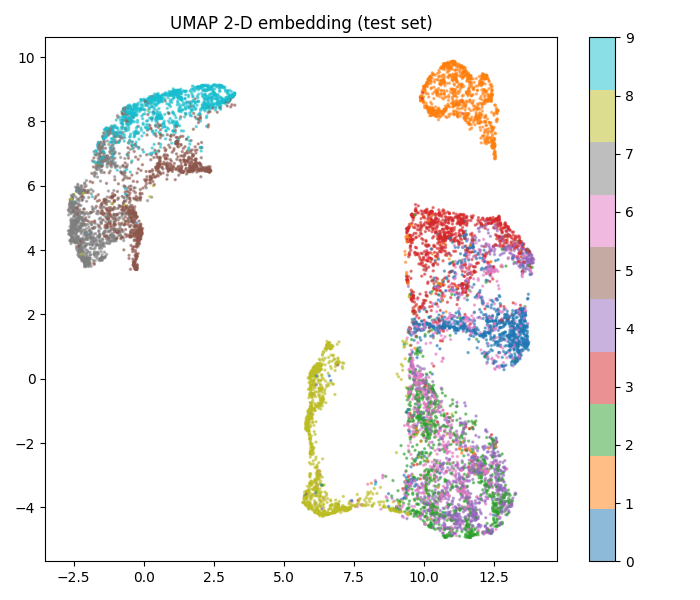

### `scatter_Raw.png`

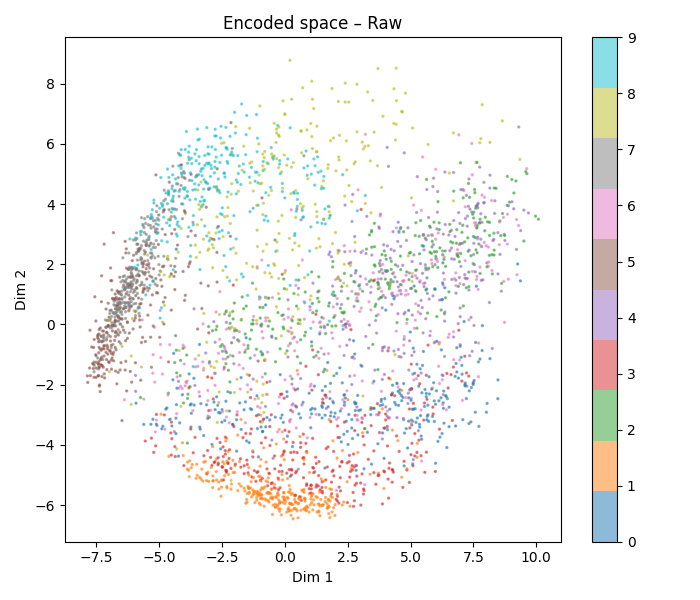

### `scatter_PCA.png`

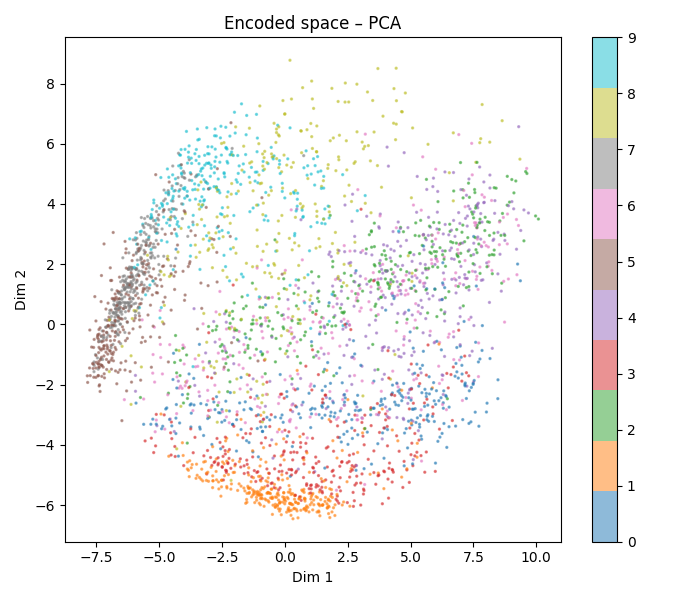

### `scatter_SAE.png`

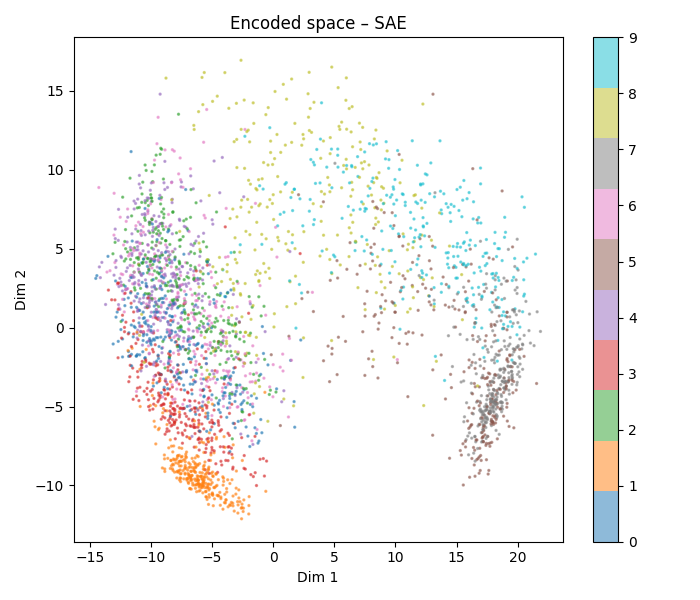

### `scatter_CNN-SAE.png`

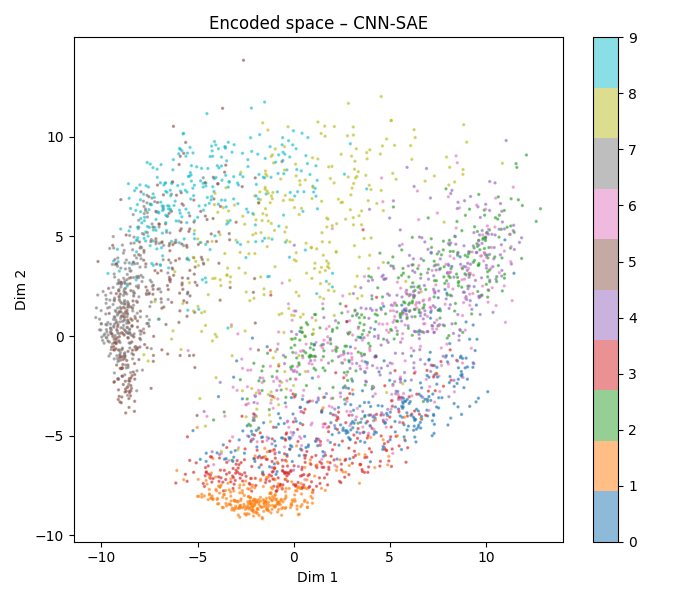

### `scatter_t-SNE.png`

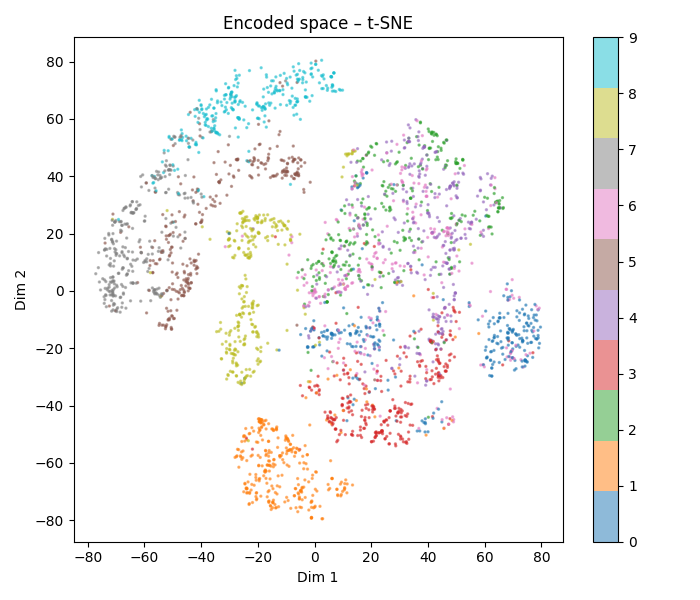

### `scatter_UMAP.png`

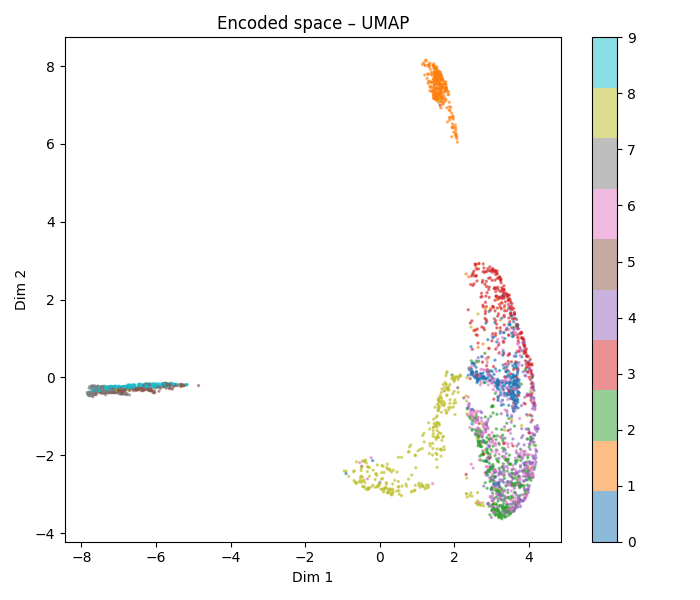

### `heatmap_silhouette.png`

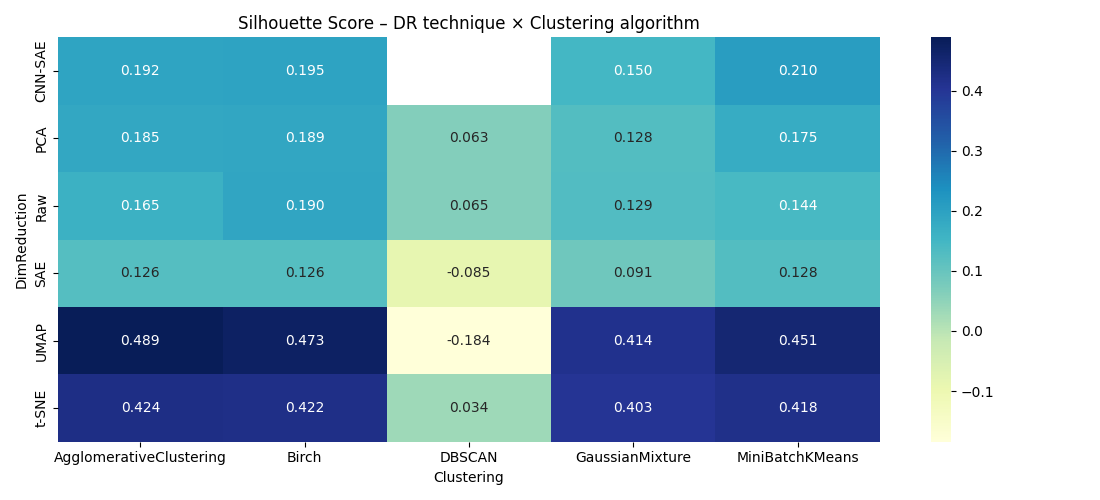

### `cluster_examples_Raw.png`

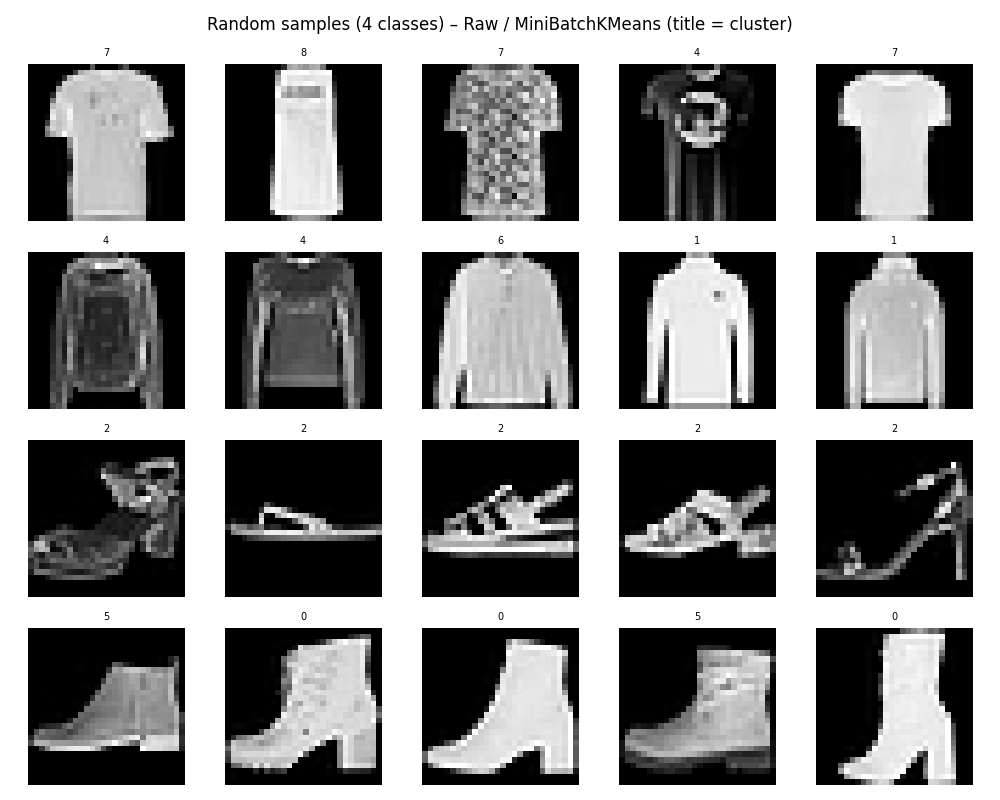

### `cluster_examples_PCA.png`

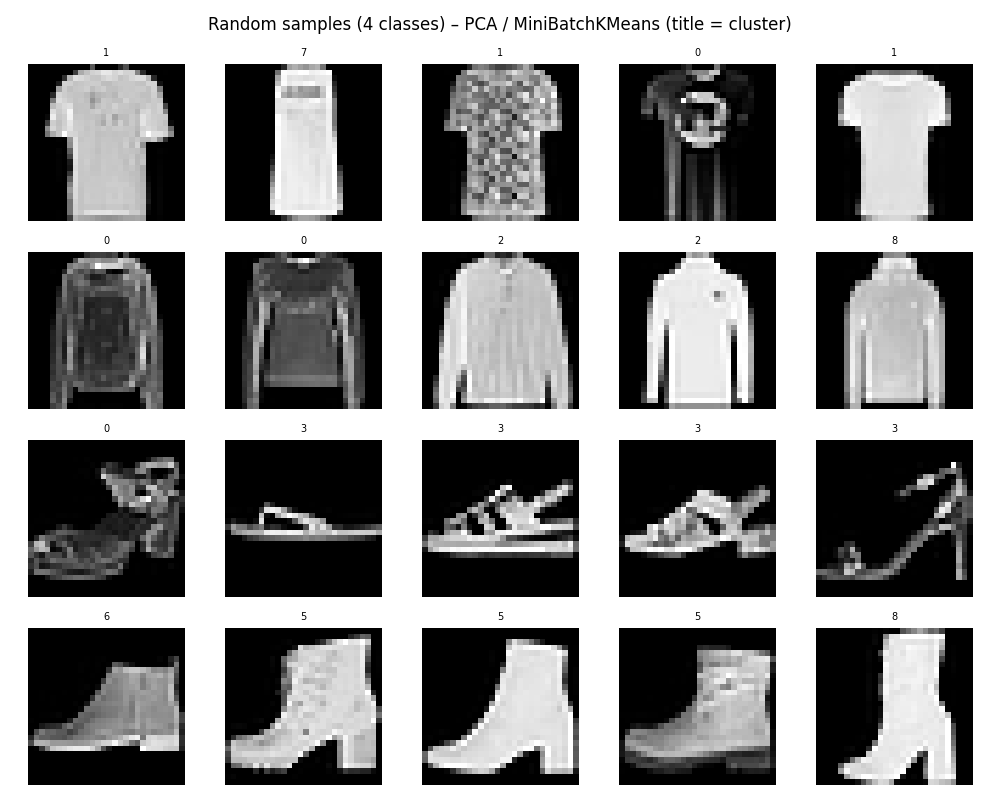

### `cluster_examples_SAE.png`

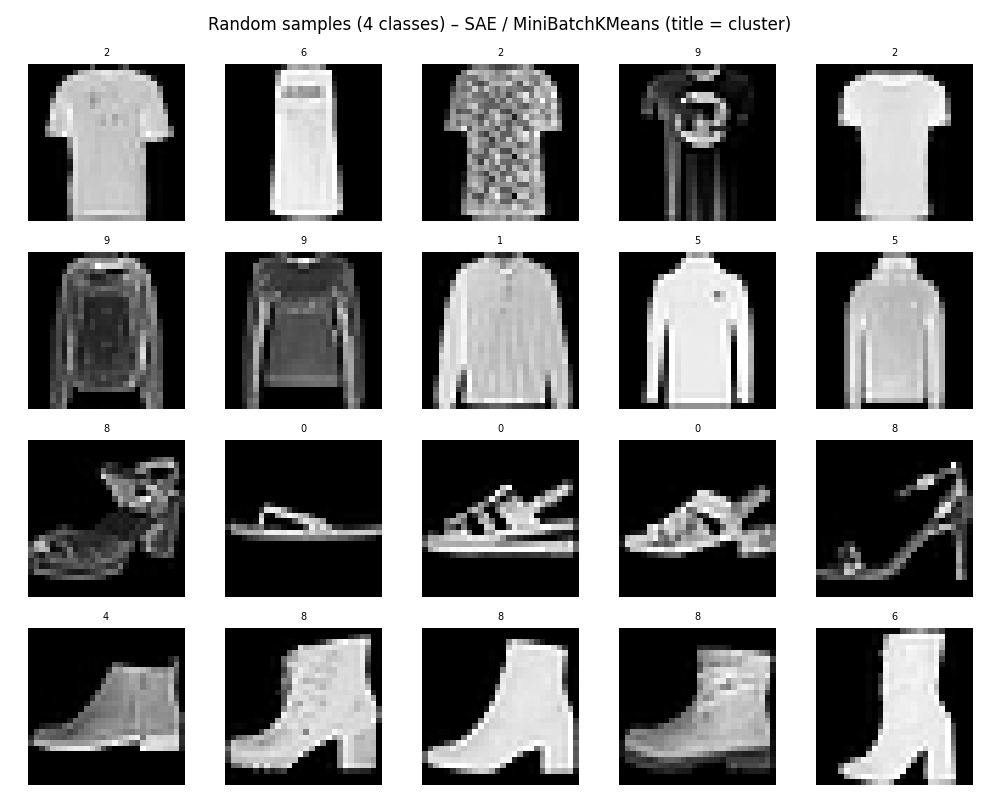

### `cluster_examples_CNN-SAE.png`

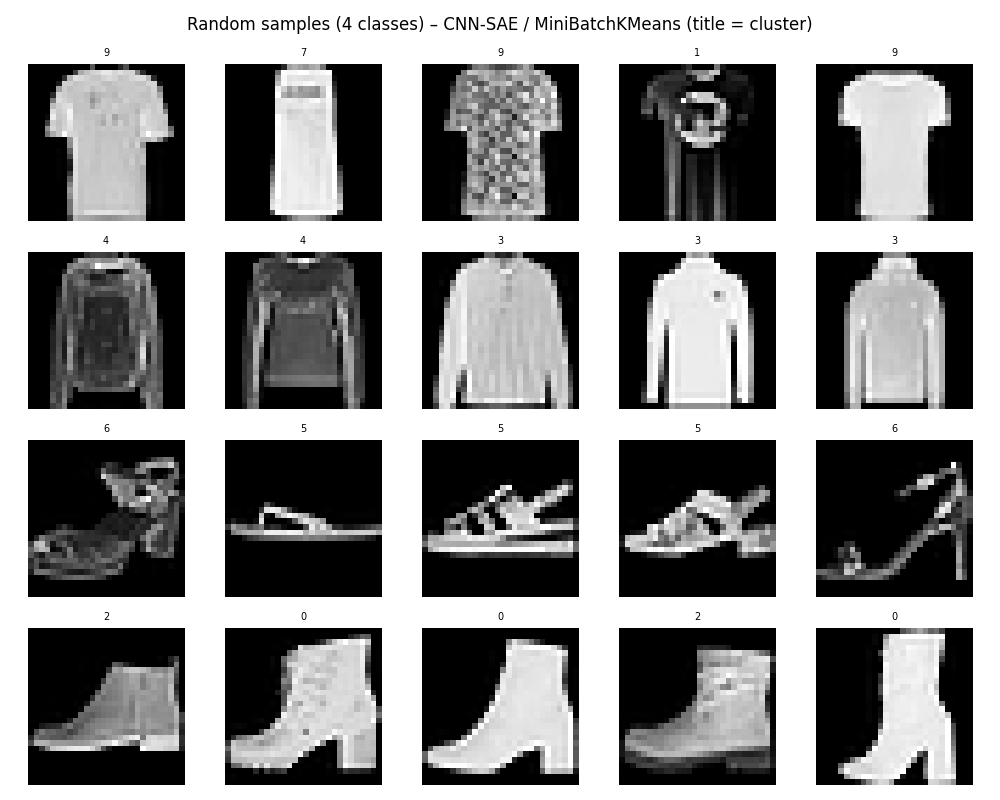

### `cluster_examples_t-SNE.png`

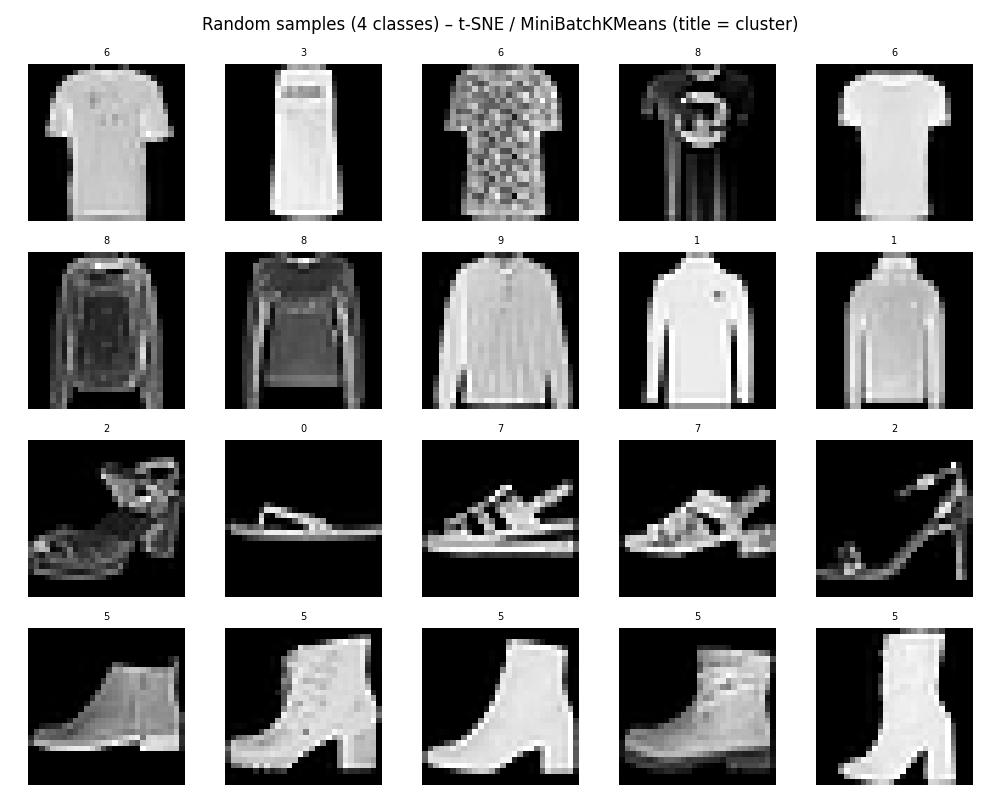

### `cluster_examples_UMAP.png`

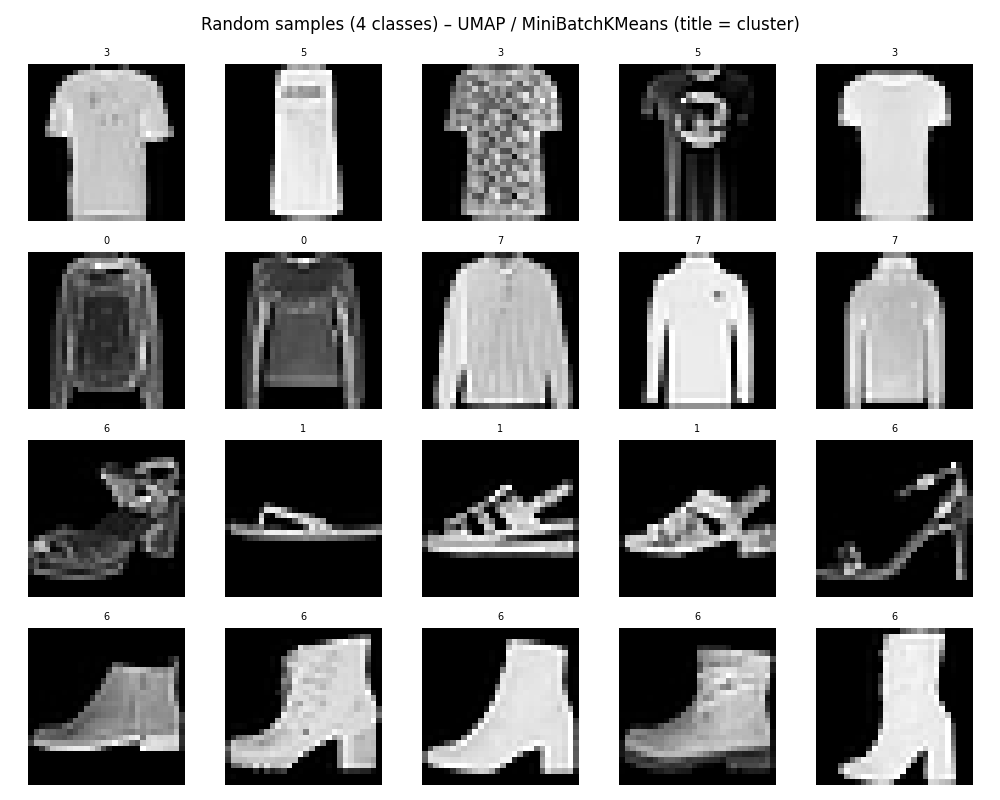

In [6]:
FIG_ORDER = [
    "00_sample_images.png",
    "pca_explained_variance.png",
    "sae_reconstructions.png",
    "cnnsae_reconstructions.png",
    "umap_2d.png",
    "scatter_Raw.png",
    "scatter_PCA.png",
    "scatter_SAE.png",
    "scatter_CNN-SAE.png",
    "scatter_t-SNE.png",
    "scatter_UMAP.png",
    "heatmap_silhouette.png",
    "cluster_examples_Raw.png",
    "cluster_examples_PCA.png",
    "cluster_examples_SAE.png",
    "cluster_examples_CNN-SAE.png",
    "cluster_examples_t-SNE.png",
    "cluster_examples_UMAP.png",
]

for name in FIG_ORDER:
    path = FIG_DIR / name
    if not path.is_file():
        display(Markdown(f"*Missing: `{path}`*"))
        continue
    display(Markdown(f"### `{name}`"))
    display(Image(filename=str(path)))